## Import needed libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, name='MedHouseVal')

In [ ]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2: 0.575787706032451


- Ridge Regression: A modification of Linear Regression that adds a penalty to the size of coefficients. This prevents "overfitting" (where the model memorizes noise) and handles multicollinearity (correlated features) better.

In [ ]:
from sklearn.linear_model import Ridge

# Train
ridge = Ridge(alpha=1.0) # alpha controls the strength of regularization
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge Regression RMSE: 0.7455567442814779


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Train
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate
print("KNN Regressor RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))

KNN Regressor RMSE: 0.6544719268995516


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Train (No scaling needed for trees, but we use it for consistency)
dt = DecisionTreeRegressor(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree RMSE: 0.7242338143386247


In [ ]:
from sklearn.svm import SVR

# Train (SVR is computationally expensive on large datasets, so we might take a while or subset data)
# We will use a subset for speed in this demo
X_train_sub = X_train_scaled[:100000]
y_train_sub = y_train[:100000]

svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_sub, y_train_sub)

# Predict
y_pred_svr = svr.predict(X_test_scaled)

# Evaluate
print("SVR (Subset) RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))

SVR (Subset) RMSE: 0.568943909879748


/tmp/ipython-input-1903383379.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')


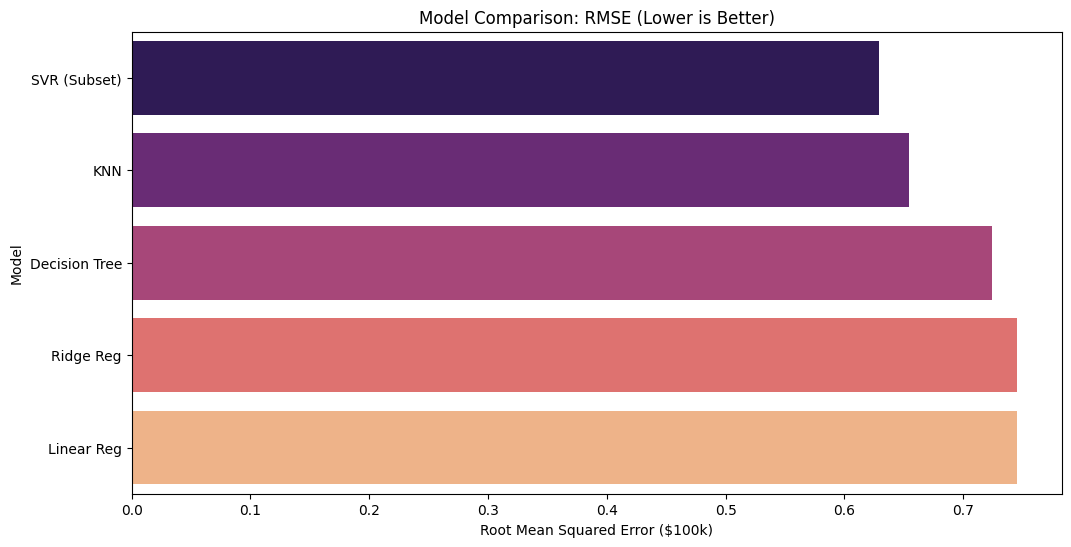

           Model      RMSE  R2 Score
4   SVR (Subset)  0.628842  0.698230
2            KNN  0.654472  0.673130
3  Decision Tree  0.724234  0.599732
1      Ridge Reg  0.745557  0.575816
0     Linear Reg  0.745581  0.575788


In [ ]:
models = {
    'Linear Reg': y_pred_lr,
    'Ridge Reg': y_pred_ridge,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    # 'Random Forest': y_pred_rf,
    'SVR (Subset)': y_pred_svr
}

results = []
for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': rmse, 'R2 Score': r2})

results_df = pd.DataFrame(results).sort_values(by='RMSE')

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')
plt.title('Model Comparison: RMSE (Lower is Better)')
plt.xlabel('Root Mean Squared Error ($100k)')
plt.show()

print(results_df)